# EXPL_06 — Operational Local Explanation

This notebook connects Explainability to the completed Operational IFB.

It builds the **exact task-specific model frame** for a 2026 operational
forecast and loads only the selected RF and XGBoost horizon artifacts.

It does not load all 48 models.


In [1]:
# Import libraries
from pathlib import Path
import sys
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "explainability.yaml"
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/explainability.yaml')

In [3]:
# Import modules for generating explainability
from src.ontario_peak_risk.explainability.common import (
    load_explainability_config,
    ensure_phase_directories,
    load_final_metadata,
)

In [4]:
# Load parameters
config, project_root = load_explainability_config(CONFIG_PATH)
phase_paths = ensure_phase_directories(config, project_root)
metadata = load_final_metadata(config, project_root)

print("Project root:", project_root)
print("RF:", metadata["rf"]["algorithm"], "| horizons:", metadata["rf"]["horizons"])
print("XGB:", metadata["xgb"]["algorithm"], "| horizons:", metadata["xgb"]["horizons"])
print("Explainability output:", phase_paths["outputs_dir"])


Project root: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk
RF: RandomForestRegressor | horizons: 24
XGB: XGBoostClassifier | horizons: 24
Explainability output: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\outputs\explainability


In [5]:
from src.ontario_peak_risk.inference_feature_builder.run_ifb import run_ifb
from src.ontario_peak_risk.explainability.model_access import load_horizon_pipeline
from src.ontario_peak_risk.explainability.shap_analysis import compute_tree_shap
from src.ontario_peak_risk.explainability.local import (
    prediction_value,
    local_contribution_table,
    human_readable_local_summary,
)
from src.ontario_peak_risk.explainability.plotting import local_contribution_plot
from src.ontario_peak_risk.explainability.reporting import write_local_report

In [6]:
# 
IFB_CONFIG = project_root / config["paths"]["ifb_config"]
FORECAST_ORIGIN = pd.Timestamp(
    config["operational_local"]["forecast_origin"]
)
FSA = config["operational_local"]["default_fsa"]
HORIZON = int(config["operational_local"]["default_horizon"])
TARGET_TIMESTAMP = FORECAST_ORIGIN + pd.Timedelta(hours=HORIZON)

print("Forecast origin:", FORECAST_ORIGIN)
print("FSA:", FSA)
print("Horizon:", HORIZON)
print("Target:", TARGET_TIMESTAMP)


Forecast origin: 2026-03-25 23:00:00
FSA: M9W
Horizon: 18
Target: 2026-03-26 17:00:00


In [7]:
# execute_models=False: we need IFB model-ready feature frames, not all 48
# predictions. This avoids the heavy all-model cold start.
ifb_result = run_ifb(
    IFB_CONFIG,
    forecast_origin=FORECAST_ORIGIN,
    fsas=list(config.get("operational_fsas", [])) or None,
    execute_models=False,
)

frames = ifb_result["feature_frames"]
print("Operational feature frames ready.")


e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\src\ontario_peak_risk\inference_feature_builder\io.py:198: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  combined[col] = combined[update].combine_first(combined.get(col))


Operational feature frames ready.


e:\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Demand forecast explanation — M9W, 2026-03-26 17:00: 15,924.0 kWh

- target_lag_24h = 15886.948577: increases forecast (SHAP=+5555.6893)
- target_lag_48h = 15969.967764: increases forecast (SHAP=+954.2901)
- target_lag_168h = 15730.545153: increases forecast (SHAP=+630.3628)
- origin__Temp (°C) = 2.7: decreases forecast (SHAP=-72.3284)
- origin__reported_premise_count = 11201: increases forecast (SHAP=+68.3145)
- origin_rolling_mean_24h = 14209.05957775: increases forecast (SHAP=+60.6591)
- target_weekday_sin = 0.43388373911755823: decreases forecast (SHAP=-44.8497)
- origin_rolling_mean_168h = 14422.61936907738: increases forecast (SHAP=+39.2293)
- fsa = M9W: increases forecast (SHAP=+38.4692)
- origin__Stn Press (kPa) = 99.0: decreases forecast (SHAP=-29.1684)


,task,horizon,feature,feature_value,shap_contribution,abs_contribution,direction
0,rf,18,target_lag_24h,15886.948577,5555.689321,5555.689321,increases forecast
1,rf,18,target_lag_48h,15969.967764,954.290097,954.290097,increases forecast
2,rf,18,target_lag_168h,15730.545153,630.362788,630.362788,increases forecast
3,rf,18,origin__Temp (°C),2.7,-72.328357,72.328357,decreases forecast
4,rf,18,origin__reported_premise_count,11201,68.314451,68.314451,increases forecast
5,rf,18,origin_rolling_mean_24h,14209.059578,60.659113,60.659113,increases forecast
6,rf,18,target_weekday_sin,0.433884,-44.849746,44.849746,decreases forecast
7,rf,18,origin_rolling_mean_168h,14422.619369,39.229321,39.229321,increases forecast
8,rf,18,fsa,M9W,38.469173,38.469173,increases forecast
9,rf,18,origin__Stn Press (kPa),99.0,-29.168374,29.168374,decreases forecast


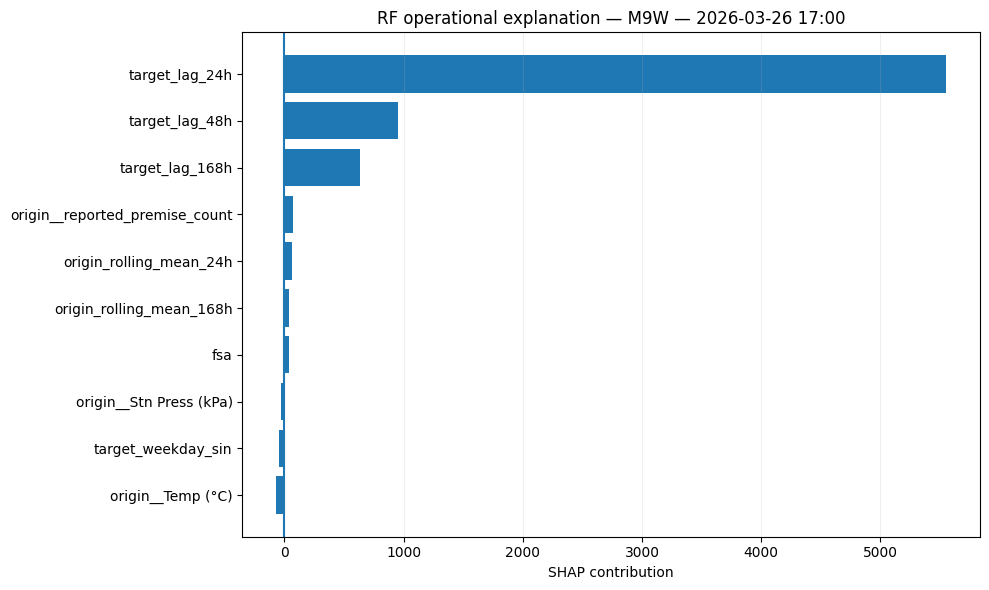


Peak-Risk explanation — M9W, 2026-03-26 17:00: score=0.759

- fsa = M9W: decreases risk score (SHAP=-1.5261)
- target_lag_24h = 15886.948577: increases risk score (SHAP=+1.4164)
- target_month_sin = 0.8660254037844386: increases risk score (SHAP=+0.7847)
- target_month_cos = 0.5000000000000001: increases risk score (SHAP=+0.6092)
- target_hour_sin = -0.9659258262890683: increases risk score (SHAP=+0.6015)
- origin__Temp (°C) = 2.7: decreases risk score (SHAP=-0.5335)
- target_hour = 17: increases risk score (SHAP=+0.4666)
- target_weekday_cos = -0.900968867902419: decreases risk score (SHAP=-0.2957)
- origin_rolling_mean_168h = 14430.53597388095: decreases risk score (SHAP=-0.2512)
- target_season = Spring: increases risk score (SHAP=+0.2490)

Note: tree SHAP contributions are interpreted on the model's native/raw output scale unless probability-output SHAP is explicitly configured. The displayed Peak-Risk probability is reported separately.


,task,horizon,feature,feature_value,shap_contribution,abs_contribution,direction
0,xgb,18,fsa,M9W,-1.526085,1.526085,decreases risk score
1,xgb,18,target_lag_24h,15886.948577,1.416357,1.416357,increases risk score
2,xgb,18,target_month_sin,0.866025,0.784727,0.784727,increases risk score
3,xgb,18,target_month_cos,0.5,0.609197,0.609197,increases risk score
4,xgb,18,target_hour_sin,-0.965926,0.601483,0.601483,increases risk score
5,xgb,18,origin__Temp (°C),2.7,-0.533479,0.533479,decreases risk score
6,xgb,18,target_hour,17,0.466554,0.466554,increases risk score
7,xgb,18,target_weekday_cos,-0.900969,-0.295688,0.295688,decreases risk score
8,xgb,18,origin_rolling_mean_168h,14430.535974,-0.251184,0.251184,decreases risk score
9,xgb,18,target_season,Spring,0.249040,0.249040,increases risk score


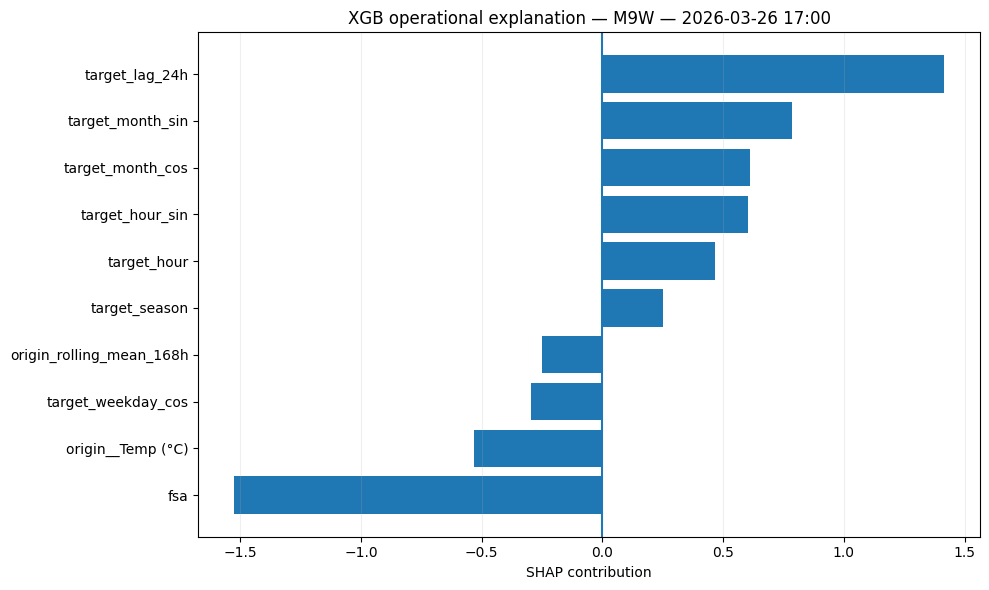

In [8]:
operational_local = {}

for task in ["rf", "xgb"]:
    task_meta = metadata[task]
    frame = frames[task][HORIZON]
    row = frame.loc[frame["fsa"].eq(FSA)].copy()

    if len(row) != 1:
        raise ValueError(
            f"Expected one operational row for {FSA}, h+{HORIZON}; "
            f"found {len(row)}."
        )

    features = (
        task_meta["numeric_features"]
        + task_meta["categorical_features"]
    )
    X = row[features].copy()

    pipeline = load_horizon_pipeline(
        task, HORIZON, config, project_root
    )
    prediction = prediction_value(pipeline, X, task)
    shap_result = compute_tree_shap(
        pipeline,
        X,
        task_meta,
        config,
        task=task,
        horizon=HORIZON,
    )
    table = local_contribution_table(
        X,
        shap_result,
        task=task,
        horizon=HORIZON,
        top_n=config["analysis"]["local_top_n"],
    )
    text = human_readable_local_summary(
        table,
        prediction=prediction,
        task=task,
        fsa=FSA,
        target_timestamp=TARGET_TIMESTAMP,
    )

    operational_local[task] = {
        "prediction": prediction,
        "table": table,
        "text": text,
    }

    print("\n" + text)
    display(table)

    local_contribution_plot(
        table,
        title=(
            f"{task.upper()} operational explanation — "
            f"{FSA} — {TARGET_TIMESTAMP:%Y-%m-%d %H:%M}"
        ),
    )
    plt.show()

    del shap_result, pipeline, X, row


In [12]:
rf_table = operational_local["rf"]["table"]
xgb_table = operational_local["xgb"]["table"]

summary_text = (
    f"Forecast origin: {FORECAST_ORIGIN}\n\n"
    f"FSA: {FSA}\n\n"
    f"Target: {TARGET_TIMESTAMP}\n\n"
    f"RF forecast: {operational_local['rf']['prediction']:,.2f} kWh\n\n"
    f"XGB Peak-Risk score: {operational_local['xgb']['prediction']:.4f}\n\n"
    f"Official alert threshold: {metadata['xgb']['operational_threshold']:.2f}"
)

write_local_report(
    phase_paths["docs_dir"] / "EXPL_06_Operational_Local_Explanation.md",
    rf_table,
    xgb_table,
    summary_text,
)

print("EXPL_06 RESULT: COMPLETE")


EXPL_06 RESULT: COMPLETE


In [18]:
# Save operational local explanation tables
rf_table.to_csv(
    phase_paths["outputs_dir"] / "EXPL_06_RF_operational_explanation.csv",
    index=False,
)

In [19]:
xgb_table.to_csv(
    phase_paths["outputs_dir"] / "EXPL_06_XGB_operational_explanation.csv",
    index=False,
)


In [20]:
print("EXPL_06 operational explanation outputs saved.")

EXPL_06 operational explanation outputs saved.
